# Bonus 03 - Coverage gallery: three promises that look green until you slice them

> "Can we put the guarantee on one slide?" - legal, five minutes before the launch review

This notebook is a small visual gallery. It is inspired by the idea of a compact coverage
illustration, but the scenario, data, plots, and language are ours: Hearthstone has two
kinds of neighborhoods, quiet streets and volatile riverfront blocks. Three interval
systems walk into the review. One has marginal coverage but poor slice behavior, one adapts
locally, and one is simply under-covered.

What you will learn:

- Why marginal coverage is a dashboard headline, not the whole dashboard.
- How the same 90% overall number can hide different experiences by slice.
- Why adaptive width is a product behavior, not just a prettier plot.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 20260707
BLUE, GREEN, AMBER, RED, GRAY, PURPLE = (
    "#2563EB", "#059669", "#F59E0B", "#DC2626", "#6B7280", "#7C3AED"
)
alpha = 0.10


## 1. A market built to expose the trap

The mean price curve is learnable. The noise is the trap. Quiet streets have small price
surprises; riverfront homes have the same average curve but much larger surprises. A
constant-width interval can look great overall while quietly spending the error budget in
the slice with the largest dollar risk.


In [2]:
rng = np.random.default_rng(RANDOM_SEED)
n = 5000
size = rng.uniform(60, 260, size=n)
riverfront = rng.binomial(1, 0.22, size=n).astype(bool)
mu = 180 + 2.2 * size + 30 * np.sin(size / 28)
sigma = np.where(riverfront, 95 + 0.22 * size, 35 + 0.06 * size)
y = mu + rng.normal(0, sigma)

z = stats.norm.ppf(1 - alpha / 2)
# System A: marginally calibrated constant band.
q_global = np.quantile(np.abs(y - mu), 1 - alpha)
lo_global, hi_global = mu - q_global, mu + q_global

# System B: locally adaptive oracle band. In production this would be estimated; here it is
# the teaching target that shows what adaptivity is trying to approximate.
lo_local, hi_local = mu - z * sigma, mu + z * sigma

# System C: the impressive-looking but wrong band.
lo_narrow, hi_narrow = mu - 0.55 * q_global, mu + 0.55 * q_global

systems = {
    "marginal constant": (lo_global, hi_global, BLUE),
    "local adaptive": (lo_local, hi_local, PURPLE),
    "too narrow": (lo_narrow, hi_narrow, RED),
}

def coverage_report(name, lo, hi):
    hit = (y >= lo) & (y <= hi)
    return pd.DataFrame({
        "system": [name, name, name],
        "slice": ["overall", "quiet streets", "riverfront"],
        "coverage": [hit.mean(), hit[~riverfront].mean(), hit[riverfront].mean()],
        "mean_width": [np.mean(hi - lo), np.mean((hi - lo)[~riverfront]), np.mean((hi - lo)[riverfront])],
    })

report = pd.concat([coverage_report(name, lo, hi) for name, (lo, hi, _) in systems.items()])
report.pivot(index="system", columns="slice", values=["coverage", "mean_width"]).round(3)


coverage                          mean_width                         
slice              overall quiet streets riverfront    overall quiet streets riverfront
system                                                                                 
local adaptive       0.900         0.901      0.896    210.962       146.875    427.958
marginal constant    0.900         0.985      0.611    222.242       222.242    222.242
too narrow           0.728         0.834      0.371    122.233       122.233    122.233

## 2. The gallery

Do not read the plots as model diagnostics; read them as a vocabulary lesson. The blue
system makes one promise to everyone. The purple system lets the interval breathe where the
market is loud. The red system is the classic overconfident dashboard: narrow, attractive,
and wrong.


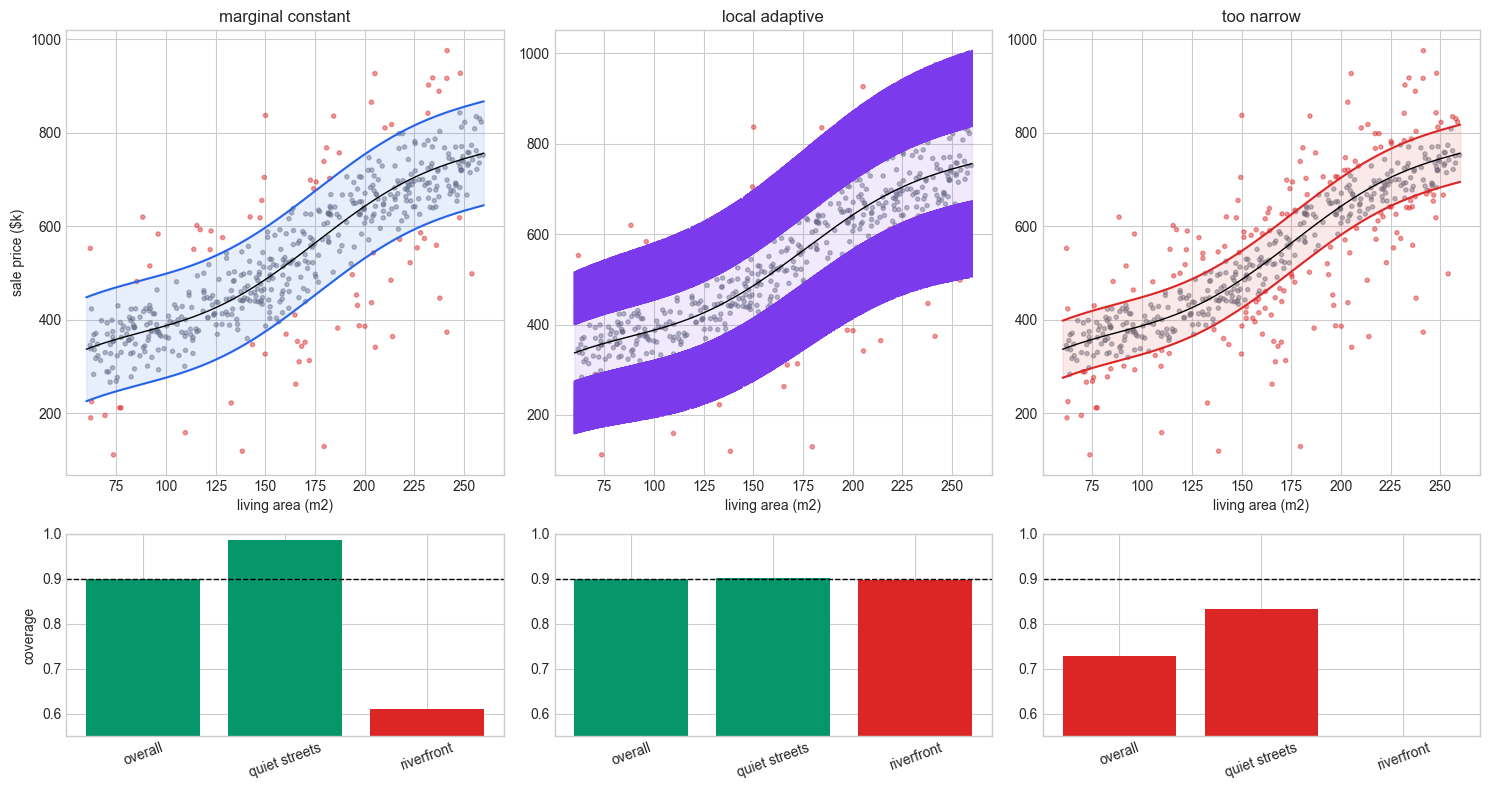

In [3]:
show_idx = np.r_[
    np.flatnonzero(~riverfront)[:350],
    np.flatnonzero(riverfront)[:180],
]
show_idx = show_idx[np.argsort(size[show_idx])]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), gridspec_kw={"height_ratios": [2.2, 1.0]})
for col, (name, (lo, hi, color)) in enumerate(systems.items()):
    ax = axes[0, col]
    hit = (y >= lo) & (y <= hi)
    ax.scatter(size[show_idx], y[show_idx], s=9, color=np.where(hit[show_idx], GRAY, RED), alpha=0.45)
    order = np.argsort(size)
    ax.plot(size[order], mu[order], color="black", linewidth=1.0, label="mean price curve")
    ax.plot(size[order], lo[order], color=color, linewidth=1.5)
    ax.plot(size[order], hi[order], color=color, linewidth=1.5)
    ax.fill_between(size[order], lo[order], hi[order], color=color, alpha=0.10)
    ax.set_title(name)
    ax.set_xlabel("living area (m2)")
    if col == 0:
        ax.set_ylabel("sale price ($k)")

    bar_ax = axes[1, col]
    rows = report[report["system"] == name].set_index("slice").loc[["overall", "quiet streets", "riverfront"]]
    colors = [GREEN if c >= 1 - alpha else RED for c in rows["coverage"]]
    bar_ax.bar(rows.index, rows["coverage"], color=colors)
    bar_ax.axhline(1 - alpha, color="black", linestyle="--", linewidth=1)
    bar_ax.set_ylim(0.55, 1.0)
    bar_ax.tick_params(axis="x", rotation=20)
    if col == 0:
        bar_ax.set_ylabel("coverage")
plt.tight_layout()


## 3. The slide legal actually needs

The launch slide should not say "coverage is 90%" and stop. It should say:

1. The marginal promise is the headline.
2. Slice coverage is the evidence that the headline is not hiding pain.
3. Width is the price paid for honesty.

That is field guide section 12 in one picture.


In [4]:
review = report.copy()
review["target"] = 1 - alpha
review["status"] = np.where(review["coverage"] >= review["target"], "green", "red")
review.sort_values(["system", "slice"]).round(3)


,system,slice,coverage,mean_width,target,status
0,local adaptive,overall,0.900,210.962,0.9,green
1,local adaptive,quiet streets,0.901,146.875,0.9,green
2,local adaptive,riverfront,0.896,427.958,0.9,red
0,marginal constant,overall,0.900,222.242,0.9,green
1,marginal constant,quiet streets,0.985,222.242,0.9,green
2,marginal constant,riverfront,0.611,222.242,0.9,red
0,too narrow,overall,0.728,122.233,0.9,red
1,too narrow,quiet streets,0.834,122.233,0.9,red
2,too narrow,riverfront,0.371,122.233,0.9,red


### The one-line summary

A coverage gallery should make one idea impossible to unsee: marginal coverage is the
front door, but slice coverage and width are the rooms where the product actually lives.
